# Audio Deepfake Detection - Project Report

**A systematic comparison of deep-learning architectures for real-vs-fake speech detection, emphasising cross-dataset generalisation and per-class behaviour under class imbalance.**

Deep Learning course project. All models are **trained and validated on Fake-or-Real (FoR)** (in-domain) and **tested on In-the-Wild (ITW)** (cross-dataset), so every headline number measures generalisation to an unseen domain rather than in-distribution fit.

---

## Executive summary

| Finding | Evidence |
|---|---|
| **Representation learning drives generalisation.** Cross-dataset AUC rises monotonically as more of the pipeline is learned. | MLP 0.79 -> CNN/CRNN 0.86-0.87 -> WavLM probe 0.92 (ITW AUC) |
| **Accuracy & AUC hide the real weakness: catching fakes.** On the real-heavy ITW set, weak models reach decent accuracy while missing most spoofed clips. | Fake-class **recall**: MLP 0.17, RNN 0.17, CRNN 0.54, CNN 0.72 |
| **Convolution carries the recurrent path.** A pure BiLSTM is weak; a CNN front-end recovers nearly all the CNN performance. | RNN AUC 0.66 vs CRNN 0.86 |
| **Under domain shift, freezing the backbone beats fine-tuning.** | FoR AUC up to 0.99 while ITW AUC down to 0.85; frozen probe ITW AUC 0.92 |
| **The spoofing cue is a mid-network acoustic feature.** | WavLM probe places ~85% weight on layer 4 of 12 |

---

## 1. Objective

Binary classification of speech as **real (bonafide)** vs **fake (spoofed / synthetic)**. Instead of fine-tuning one pretrained model, the project asks *which inductive biases actually help*, by comparing four families that differ in how much of the pipeline is learned from data:

| # | Family | Input representation | What it tests |
|---|--------|----------------------|---------------|
| 1 | **MLP** | hand-crafted features (MFCC, chroma, spectral contrast, ZCR) | classical features + shallow classifier |
| 2 | **CNN** | mel-spectrogram | learned 2-D spectral features |
| 3 | **RNN / CRNN** | mel-spectrogram as a time series | temporal modelling (BiLSTM), with / without a CNN front-end |
| 4 | **WavLM** | raw waveform | self-supervised transformer (`microsoft/wavlm-base-plus`) - frozen probe vs full fine-tune |

Families 1-3 get focused **one-axis ablations** (capacity, learning rate, regularisation). Family 4 is an analysis of *how* to use a pretrained backbone. The research contribution is the **comparative analysis**, not the use of any one model.


## 2. Datasets & evaluation protocol

| Split | Dataset | Role |
|-------|---------|------|
| Train + Validation | **Fake-or-Real (FoR)**, `for-norm` | in-domain fitting & model selection |
| Test | **In-the-Wild (ITW)**, trimmed + normalised | **cross-dataset** generalisation |

**Cross-dataset by design.** Testing on a split of the *training* corpus overstates anti-spoofing performance because models latch onto corpus-specific artefacts. Training on FoR and testing on the independently collected ITW set (**31,779 clips - 19,963 real / 11,816 fake**) gives an honest estimate, and the FoR->ITW gap is itself a key diagnostic.

**Class imbalance.** ITW is **~63% real / 37% fake**. A model that simply leans "real" can post a deceptively high accuracy while failing at the actual job (flagging fakes). We therefore report **per-class precision/recall/F1**, and treat **fake-class recall** - the fraction of spoofed clips actually caught - as the operationally important number alongside AUC.

**Preprocessing.** 16 kHz mono; fixed-duration center-crop/pad. Feature scalers are **fit on the clean training split only** and reused unchanged at test time (no leakage). Train-time noise augmentation (Section 7) is applied to the **training split only**.

**Metrics.** AUC-ROC (threshold-free, primary), accuracy, per-class precision/recall/F1. EER is the conventional anti-spoofing headline; per-sample scores were not retained, so EER is a follow-up (Section 10).


## 3. Setup
The cells below load the **committed** experiment results under `results/` - this notebook presents them, it does not retrain. Run from the repository root.

In [1]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# --- shared visual style -------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#22303a",
    "axes.edgecolor": "#9aa7b0",
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#c9d3da",
    "grid.alpha": 0.5,
    "grid.linewidth": 0.7,
    "xtick.color": "#42505a",
    "ytick.color": "#42505a",
    "text.color": "#22303a",
})
# cohesive palette (teal / blue / amber / coral / violet / slate)
PAL = {"teal": "#0E9594", "blue": "#3E7CB1", "amber": "#E9B949",
       "coral": "#E8674F", "violet": "#8E7CC3", "slate": "#5C6B73",
       "ink": "#22303a", "mute": "#cfd8dd"}

ROOT = Path.cwd()
RESULTS = ROOT / "results"

def load_summary(rel):
    return pd.read_csv(RESULTS / rel).sort_values("auc", ascending=False).reset_index(drop=True)

FAM = {"MLP": "nn_experiments/simple_nn", "CNN": "cnn_experiments/cnn",
       "CRNN": "crnn_experiments/crnn", "RNN": "rnn_experiments/rnn"}
summ = {k: load_summary(f"{v}/comparison/metrics_summary.csv") for k, v in FAM.items()}
print("Runs per family:", {k: len(v) for k, v in summ.items()})

def _parse_clf(p):
    t = Path(p).read_text(); out = {}
    for cls in ("Real", "Fake"):
        m = re.search(cls + r"\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)", t)
        out[cls] = tuple(float(x) for x in m.groups()[:3])
    return out

def family_metrics(fam, sub):
    rows = []
    for _, r in summ[fam].iterrows():
        tag = r["tag"]
        rep = _parse_clf(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
        Rf, (Fp, Fr, Ff) = rep["Real"][2], rep["Fake"]
        rows.append({"tag": tag, "AUC": r["auc"], "accuracy": r["test_acc"],
                     "macro_F1": (Rf + Ff) / 2, "fake_recall": Fr})
    return pd.DataFrame(rows)

_ABBR = {"depth": "depth", "base_channels": "ch", "lr": "lr", "dropout": "do",
         "weight_decay": "wd", "cnn_depth": "cd", "num_rnn_layers": "rl",
         "rnn_hidden": "rh", "num_layers": "L", "hidden_size": "h", "hidden_sizes": "h"}

def _fmt(v):
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    if isinstance(v, (float, np.floating)):
        return f"{v:.0e}".replace("e-0", "e-").replace("e+0", "e") if (v != 0 and abs(v) < 1e-2) else f"{v:g}"
    return str(v)

def plot_family(fam, sub):
    # labels built from the ACTUAL hyperparameter values (same as the table), not the tag
    d = family_table(fam, sub).iloc[::-1].reset_index(drop=True)   # ascending AUC for barh
    cols = CONFIG_COLS[fam]
    labels = [", ".join(f"{_ABBR.get(c, c)}={_fmt(r[c])}" for c in cols) for _, r in d.iterrows()]
    y = np.arange(len(d)); h = 0.2
    mets = [("AUC", "AUC", PAL["teal"]), ("accuracy", "accuracy", PAL["blue"]),
            ("macro_F1", "macro-F1", PAL["amber"]), ("fake_R", "fake recall", PAL["coral"])]
    plt.figure(figsize=(10, 0.6 * len(d) + 1.8))
    for i, (col, lab, c) in enumerate(mets):
        off = (1.5 - i) * h
        plt.barh(y + off, d[col], h, label=lab, color=c, edgecolor="white", linewidth=0.4)
    plt.yticks(y, labels, fontsize=7.5); plt.xlim(0, 1.0); plt.xlabel("score")
    plt.title(f"{fam}: performance metrics across configurations")
    plt.legend(loc="lower right", ncol=2, fontsize=8, framealpha=0.9)
    plt.tight_layout(); plt.show()

CONFIG_COLS = {
    "MLP":  ["hidden_sizes", "lr", "dropout", "weight_decay"],
    "CNN":  ["depth", "base_channels", "lr", "dropout", "weight_decay"],
    "CRNN": ["cnn_depth", "base_channels", "num_rnn_layers", "rnn_hidden", "lr", "dropout", "weight_decay"],
    "RNN":  ["num_layers", "hidden_size", "lr", "dropout", "weight_decay"],
}

def family_table(fam, sub):
    # per-configuration table: actual hyperparameter values + saved per-class metrics
    rows = []
    for _, r in summ[fam].iterrows():
        tag = r["tag"]
        rep = _parse_clf(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
        (Rp, Rr, Rf), (Fp, Fr, Ff) = rep["Real"], rep["Fake"]
        row = {c: r[c] for c in CONFIG_COLS[fam]}
        row.update({"AUC": r["auc"], "accuracy": r["test_acc"], "macro_F1": (Rf + Ff) / 2,
                    "real_P": Rp, "real_R": Rr, "real_F1": Rf,
                    "fake_P": Fp, "fake_R": Fr, "fake_F1": Ff})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)

def _sortkey(v):
    try:
        return (0, float(v), 0)
    except (TypeError, ValueError):
        nums = [int(x) for x in re.findall(r"\d+", str(v))]
        return (1, len(nums), nums[0] if nums else 0)

def plot_hparam_effects(fam, sub, metrics=("AUC", "accuracy", "macro_F1")):
    # controlled one-axis view: vary ONE hyperparameter, hold the others at the baseline
    import math
    d = family_table(fam, sub)
    cols = CONFIG_COLS[fam]
    base = {c: d[c].mode().iloc[0] for c in cols}          # baseline = most common value per axis
    mc = {"AUC": PAL["teal"], "accuracy": PAL["blue"], "macro_F1": PAL["amber"], "fake_R": PAL["coral"]}
    specs = []
    for h in cols:
        others = [c for c in cols if c != h]
        if others:
            mask = (d[others] == pd.Series({c: base[c] for c in others})).all(axis=1)
            sd = d[mask]
        else:
            sd = d
        if sd[h].nunique() >= 2:
            specs.append((h, sd))
    n = len(specs); ncol = min(3, n); nrow = math.ceil(n / ncol)
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.3 * ncol, 3.2 * nrow), squeeze=False)
    for ax in axs.flat:
        ax.set_visible(False)
    for k, (h, sd) in enumerate(specs):
        ax = axs[k // ncol][k % ncol]; ax.set_visible(True)
        sd = sd.assign(_sk=sd[h].map(_sortkey)).sort_values("_sk")
        xpos = np.arange(len(sd)); xlab = [_fmt(v) for v in sd[h]]
        for met in metrics:
            ax.plot(xpos, sd[met], marker="o", ms=5, lw=2, color=mc.get(met), label=met.replace("_", "-"))
        bi = [i for i, v in enumerate(sd[h]) if _fmt(v) == _fmt(base[h])]
        if bi:
            ax.axvline(bi[0], color=PAL["slate"], ls=":", lw=1.1, alpha=0.75)
            ax.text(bi[0], 0.47, "baseline", rotation=90, fontsize=7, color=PAL["slate"], va="bottom", ha="right")
        ax.set_xticks(xpos); ax.set_xticklabels(xlab, fontsize=8)
        ax.set_title(_ABBR.get(h, h), fontsize=10, fontweight="bold")
        ax.set_ylim(0.45, 1.0); ax.grid(alpha=0.3); ax.set_xlabel(h, fontsize=8)
    axs[0][0].legend(fontsize=8, loc="lower right")
    fig.suptitle(f"{fam}: effect of each hyperparameter (others held at baseline)", fontweight="bold", y=1.0)
    fig.tight_layout(); plt.show()

Runs per family: {'MLP': 10, 'CNN': 10, 'CRNN': 10, 'RNN': 10}


## 4. Architecture 1 - MLP on hand-crafted features
A shallow fully-connected network over classical descriptors (MFCC, chroma, spectral contrast, ZCR) aggregated per clip. No representation learning - the baseline.

**Ablation:** hidden width / depth, learning rate, dropout, weight decay.

In [2]:
family_table("MLP", "nn_experiments/simple_nn")

,hidden_sizes,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,"[256, 128, 64]",0.0010,0.5000,0.0001,0.7864,0.6832,0.5436,0.6667,0.9873,0.7960,0.8914,0.1740,0.2912
1,"[256, 128, 64]",0.0005,0.5000,0.0001,0.7694,0.6629,0.4989,0.6527,0.9865,0.7856,0.8433,0.1214,0.2122
2,[128],0.0005,0.5000,0.0001,0.7600,0.6630,0.4948,0.6519,0.9904,0.7863,0.8771,0.1150,0.2033
3,"[256, 128, 64, 32]",0.0005,0.5000,0.0001,0.7588,0.6687,0.5147,0.6572,0.9841,0.7881,0.8414,0.1409,0.2413
4,"[256, 128]",0.0005,0.5000,0.0001,0.7493,0.6688,0.5126,0.6568,0.9863,0.7885,0.8571,0.1373,0.2367
5,"[256, 128, 64]",0.0005,0.5000,0.0010,0.7488,0.6725,0.5231,0.6598,0.9842,0.7900,0.8506,0.1507,0.2561
6,"[512, 256, 128, 64]",0.0005,0.5000,0.0001,0.7416,0.6636,0.4986,0.6528,0.9883,0.7863,0.8599,0.1203,0.2110
7,"[256, 128, 64]",0.0005,0.3000,0.0001,0.7316,0.6667,0.5086,0.6555,0.9855,0.7873,0.8454,0.1331,0.2299
8,"[256, 128, 64]",0.0001,0.5000,0.0001,0.7304,0.6520,0.4781,0.6461,0.9817,0.7793,0.7657,0.1001,0.1770
9,"[512, 256, 128]",0.0005,0.5000,0.0001,0.6941,0.6587,0.4908,0.6501,0.9847,0.7832,0.8152,0.1130,0.1984


**How to read the next plots.** The bar chart above ranks whole configurations. The panels below isolate the effect of *one* hyperparameter at a time: in each panel a single axis is varied while the others are held at the baseline, so the slope shows that hyperparameter\u2019s genuine contribution to performance.

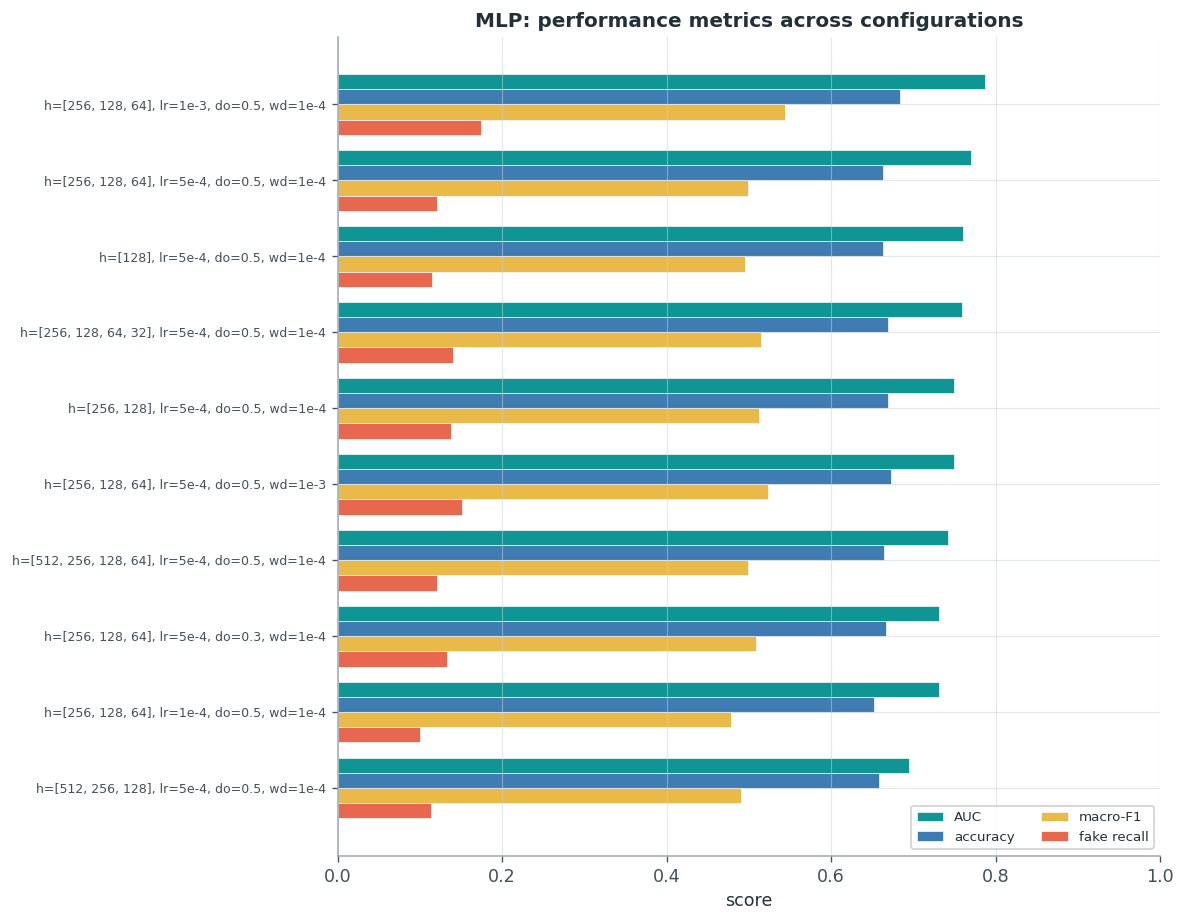

In [3]:
plot_family("MLP", "nn_experiments/simple_nn")

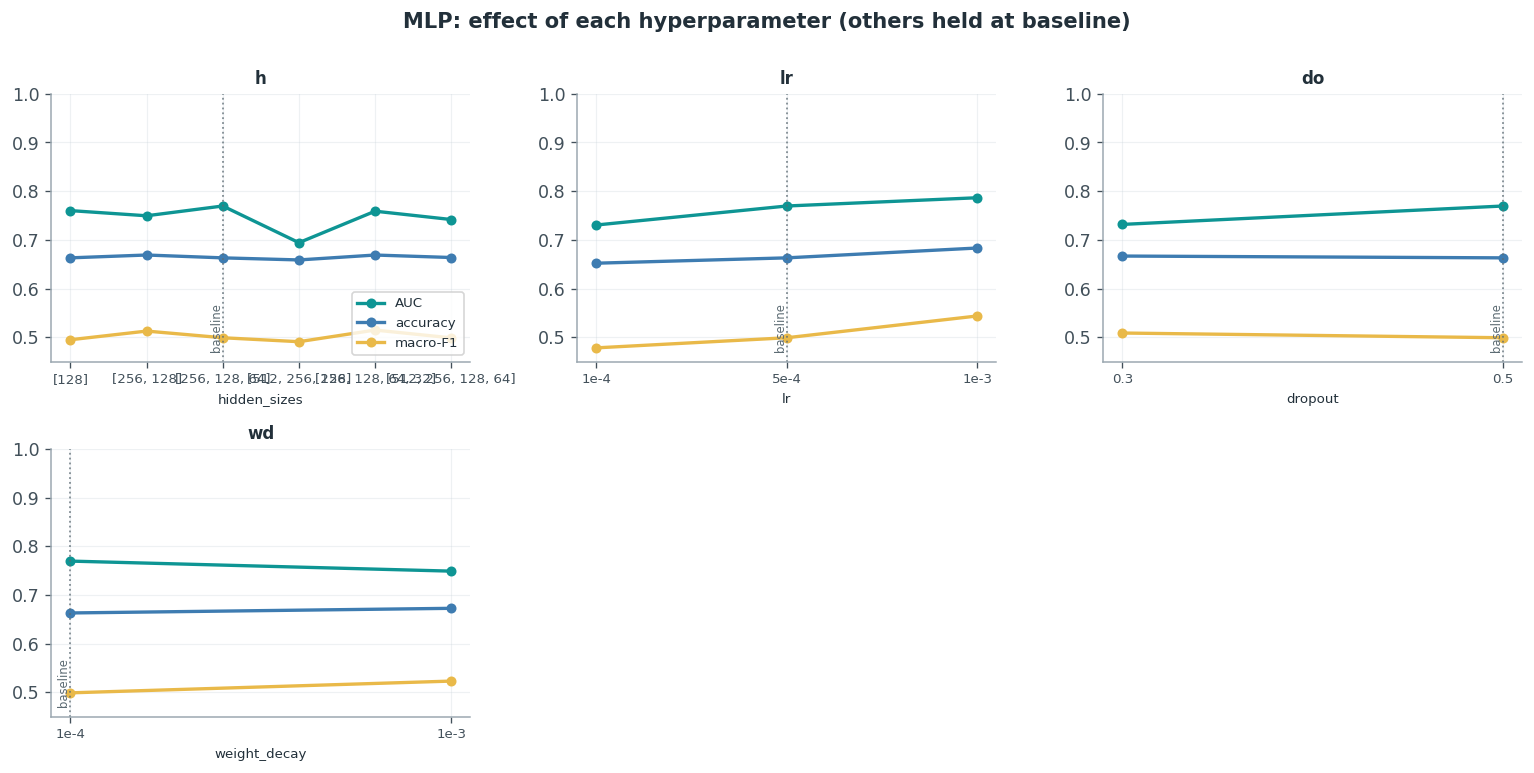

In [4]:
plot_hparam_effects("MLP", "nn_experiments/simple_nn")

**Interpretation.** Caps at **AUC ~ 0.79 / acc ~ 0.68** - above chance but the weakest learned model.

- **Capacity does not help.** The widest nets (`512-256-128(-64)`) do *worse*: they overfit FoR-specific structure and transfer less well. Best is a modest `256-128-64`.
- **Learning rate dominates.** `1e-3` clearly beats `5e-4`/`1e-4` - the low-dimensional feature space has a benign loss surface where a larger step finds a better basin within the epoch budget.

The ceiling is set by the **features**, not the classifier: hand-crafted descriptors discard the fine spectro-temporal detail that exposes modern synthesis artefacts. (Section 8 shows this MLP also has near-zero fake recall - it mostly predicts real.)

## 5. Architecture 2 - CNN on mel-spectrograms
A 2-D CNN over the mel-spectrogram, learning local spectro-temporal filters end-to-end.

**Ablation:** conv depth, base channels, learning rate, dropout, weight decay.

In [5]:
family_table("CNN", "cnn_experiments/cnn")

,depth,base_channels,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,3,32,0.0010,0.5000,0.0001,0.8702,0.8266,0.8103,0.8418,0.8914,0.8659,0.7963,0.7170,0.7546
1,3,64,0.0005,0.5000,0.0001,0.8640,0.8146,0.7856,0.7994,0.9408,0.8644,0.8575,0.6012,0.7068
2,4,32,0.0005,0.5000,0.0001,0.8377,0.7778,0.7364,0.7641,0.9350,0.8410,0.8234,0.5124,0.6317
3,3,32,0.0005,0.3000,0.0001,0.7712,0.7411,0.6885,0.7359,0.9169,0.8165,0.7599,0.4441,0.5605
4,3,16,0.0005,0.5000,0.0001,0.7091,0.6605,0.6469,0.7543,0.6817,0.7161,0.5374,0.6248,0.5778
5,3,32,0.0005,0.5000,0.0001,0.6814,0.6703,0.6302,0.7129,0.7956,0.7520,0.5705,0.4586,0.5085
6,3,32,0.0005,0.5000,0.0000,0.6705,0.6556,0.6247,0.7153,0.7505,0.7325,0.5402,0.4953,0.5168
7,3,32,0.0005,0.5000,0.0010,0.5644,0.5252,0.5223,0.6707,0.4796,0.5593,0.4065,0.6021,0.4853
8,2,32,0.0005,0.5000,0.0001,0.5484,0.5288,0.5216,0.6588,0.5184,0.5802,0.4017,0.5464,0.4630
9,3,32,0.0001,0.5000,0.0001,0.5479,0.5198,0.5154,0.6588,0.4886,0.5610,0.3985,0.5725,0.4699


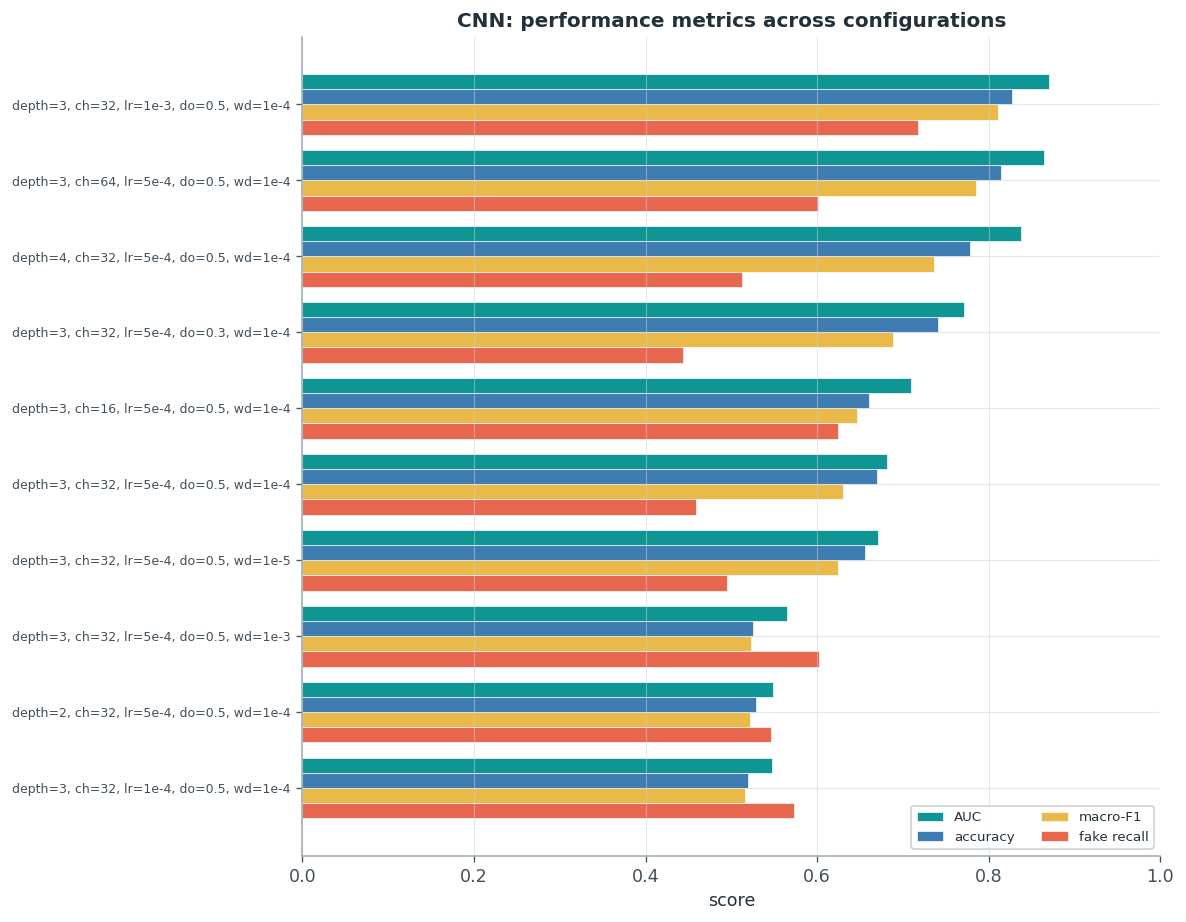

In [6]:
plot_family("CNN", "cnn_experiments/cnn")

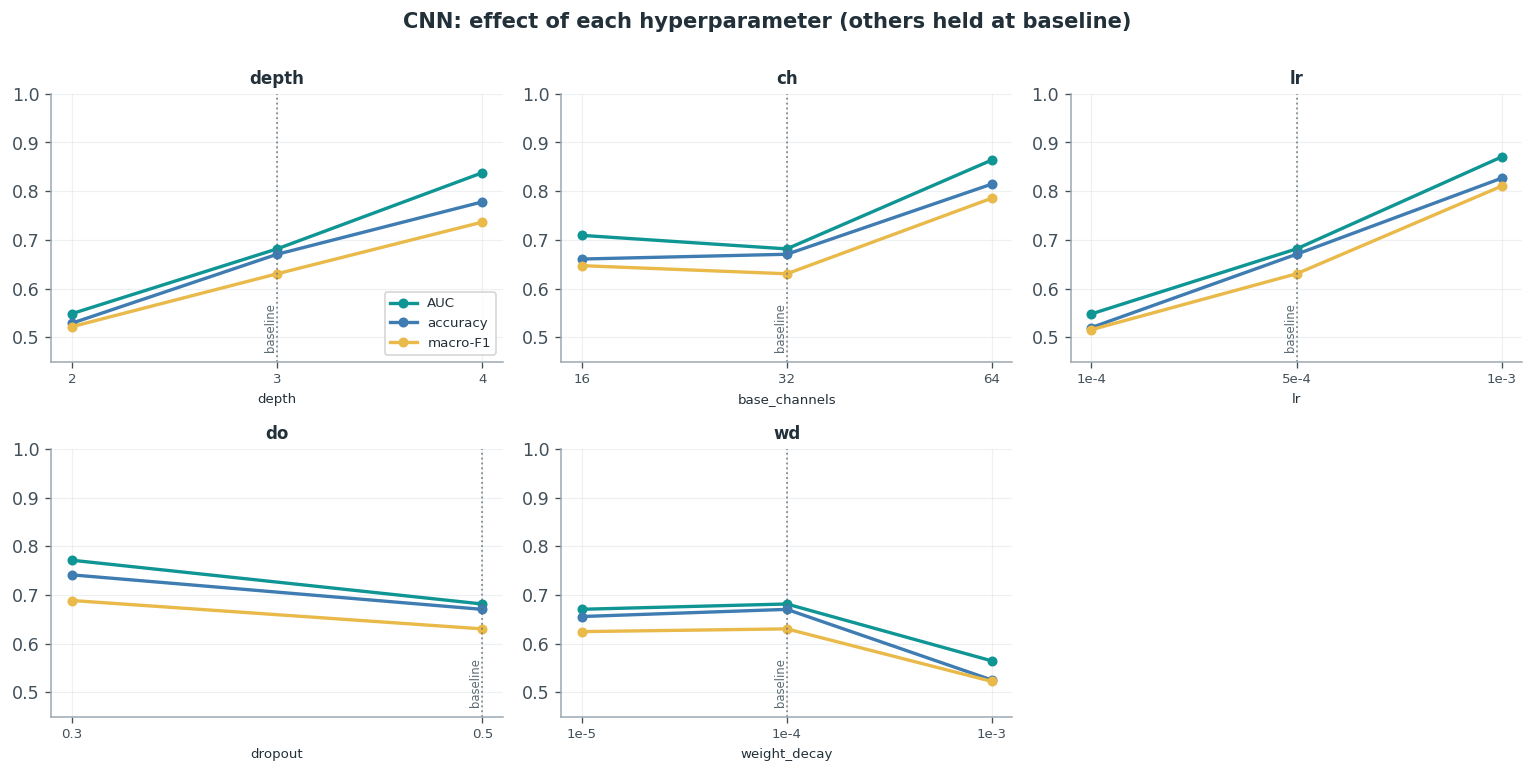

In [7]:
plot_hparam_effects("CNN", "cnn_experiments/cnn")

**Interpretation.** The **strongest non-pretrained model: AUC ~ 0.87 / acc ~ 0.83**, and the best fake-recall of any model here.

- **Depth has a sweet spot.** 3 conv blocks is best; 4 hurts, 2 collapses (AUC 0.55).
- **Enough width is necessary, more is not free.** 16 channels underperforms, 32 is the sweet spot, 64 adds nothing.
- **Regularisation is delicate.** Weight decay `1e-3` is catastrophic (AUC 0.56); `1e-4` is right. Dropout 0.5 > 0.3.
- Best: **`depth 3, ch 32, lr 1e-3, dropout 0.5, wd 1e-4`**.

## 6. Architecture 3 - Recurrent models (RNN & CRNN)
Two temporal variants on the same mel input: a pure **BiLSTM (RNN)** over frame vectors, and a **CRNN** with a CNN front-end before the BiLSTM.

**Ablation:** recurrent layers, hidden size, (CRNN) conv depth/channels, learning rate, dropout.

In [8]:
print("=== CRNN ==="); display(family_table("CRNN", "crnn_experiments/crnn"))
print("\n=== RNN (pure BiLSTM) ==="); display(family_table("RNN", "rnn_experiments/rnn"))

=== CRNN ===


,cnn_depth,base_channels,num_rnn_layers,rnn_hidden,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,3,32,2,128,0.0005,0.5000,0.0001,0.8596,0.8054,0.7667,0.7783,0.9651,0.8617,0.9008,0.5355,0.6717
1,4,32,2,128,0.0005,0.5000,0.0001,0.8388,0.7899,0.7688,0.8101,0.8693,0.8387,0.7481,0.6558,0.6989
2,3,32,3,128,0.0005,0.5000,0.0001,0.8313,0.7541,0.7074,0.7478,0.9184,0.8244,0.7757,0.4766,0.5904
3,3,32,2,128,0.0005,0.3000,0.0001,0.7549,0.7354,0.6940,0.7457,0.8784,0.8066,0.7062,0.4939,0.5813
4,3,16,2,128,0.0005,0.5000,0.0001,0.7444,0.6791,0.5531,0.6702,0.9632,0.7904,0.7622,0.1991,0.3157
5,3,64,2,128,0.0005,0.5000,0.0001,0.7328,0.7313,0.6970,0.7538,0.8499,0.7990,0.6768,0.5309,0.5950
6,3,32,1,128,0.0005,0.5000,0.0001,0.7203,0.7220,0.6898,0.7523,0.8310,0.7897,0.6532,0.5378,0.5899
7,2,32,2,128,0.0005,0.5000,0.0001,0.6045,0.6264,0.5856,0.6857,0.7484,0.7157,0.4972,0.4203,0.4555
8,3,32,2,128,0.0010,0.5000,0.0001,0.5565,0.5269,0.5200,0.6575,0.5153,0.5778,0.4003,0.5465,0.4621
9,3,32,2,128,0.0001,0.5000,0.0001,0.5488,0.5694,0.5413,0.6595,0.6504,0.6549,0.4227,0.4325,0.4276



=== RNN (pure BiLSTM) ===


,num_layers,hidden_size,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,1,128,0.0005,0.5000,0.0001,0.6596,0.6524,0.5191,0.6562,0.9384,0.7723,0.6194,0.1693,0.2659
1,2,128,0.0010,0.5000,0.0001,0.6496,0.6586,0.5534,0.6673,0.9105,0.7701,0.6064,0.2330,0.3366
2,2,128,0.0005,0.3000,0.0001,0.6332,0.6583,0.5426,0.6638,0.9244,0.7727,0.6204,0.2089,0.3125
3,3,128,0.0005,0.5000,0.0001,0.6239,0.6505,0.5159,0.6550,0.9375,0.7712,0.6106,0.1656,0.2606
4,2,128,0.0001,0.5000,0.0001,0.5926,0.6436,0.5624,0.6693,0.8552,0.7509,0.5391,0.2861,0.3739
5,2,128,0.0005,0.5000,0.0001,0.5919,0.6465,0.4902,0.6484,0.9552,0.7724,0.6225,0.1249,0.2081
6,2,64,0.0005,0.5000,0.0001,0.5802,0.6498,0.5069,0.6527,0.9456,0.7723,0.6200,0.1500,0.2415
7,2,256,0.0005,0.5000,0.0001,0.5714,0.6379,0.5222,0.6540,0.8994,0.7573,0.5357,0.1961,0.2871
8,2,128,0.0005,0.5000,0.0000,0.5682,0.6487,0.5168,0.6548,0.9323,0.7693,0.5971,0.1696,0.2642
9,2,128,0.0005,0.5000,0.0010,0.4873,0.4566,0.4563,0.6075,0.3811,0.4684,0.3584,0.5840,0.4442


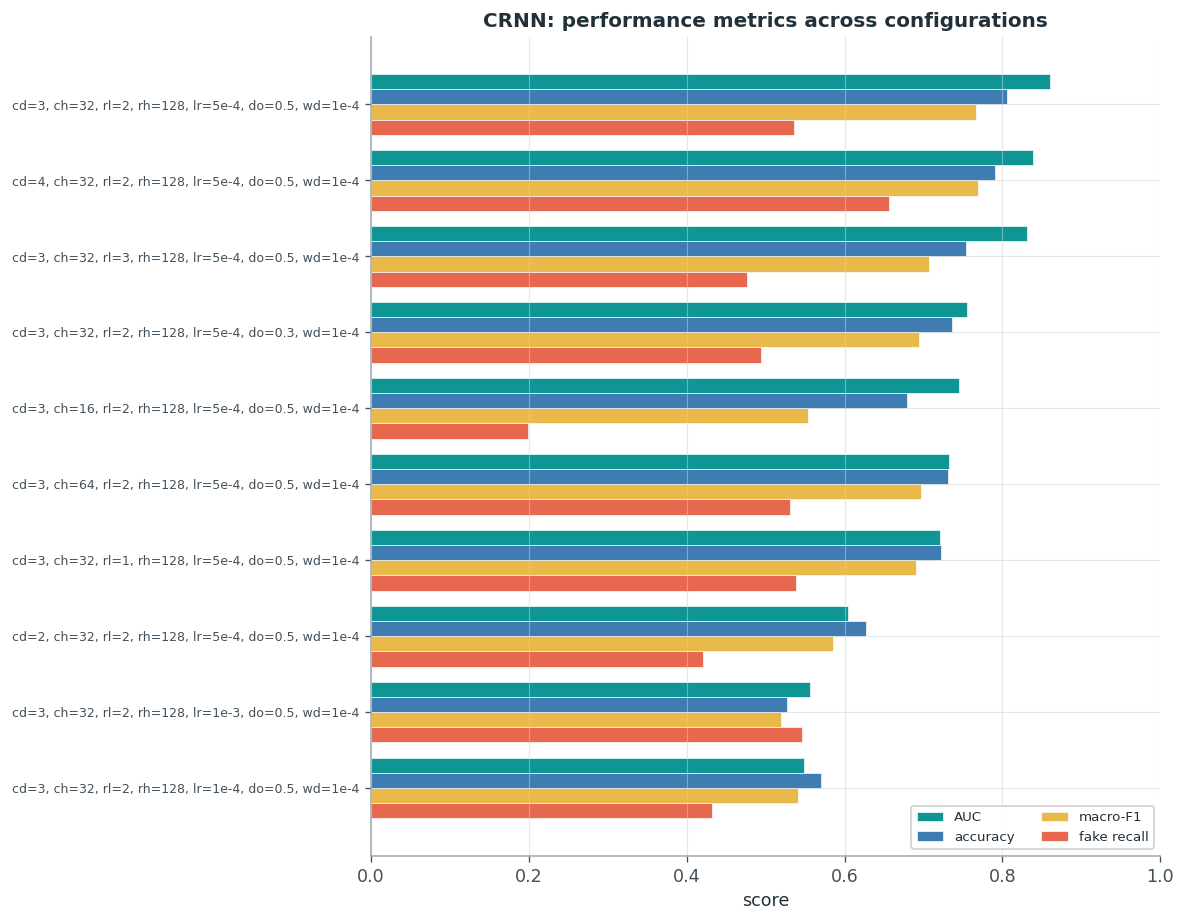

In [9]:
plot_family("CRNN", "crnn_experiments/crnn")

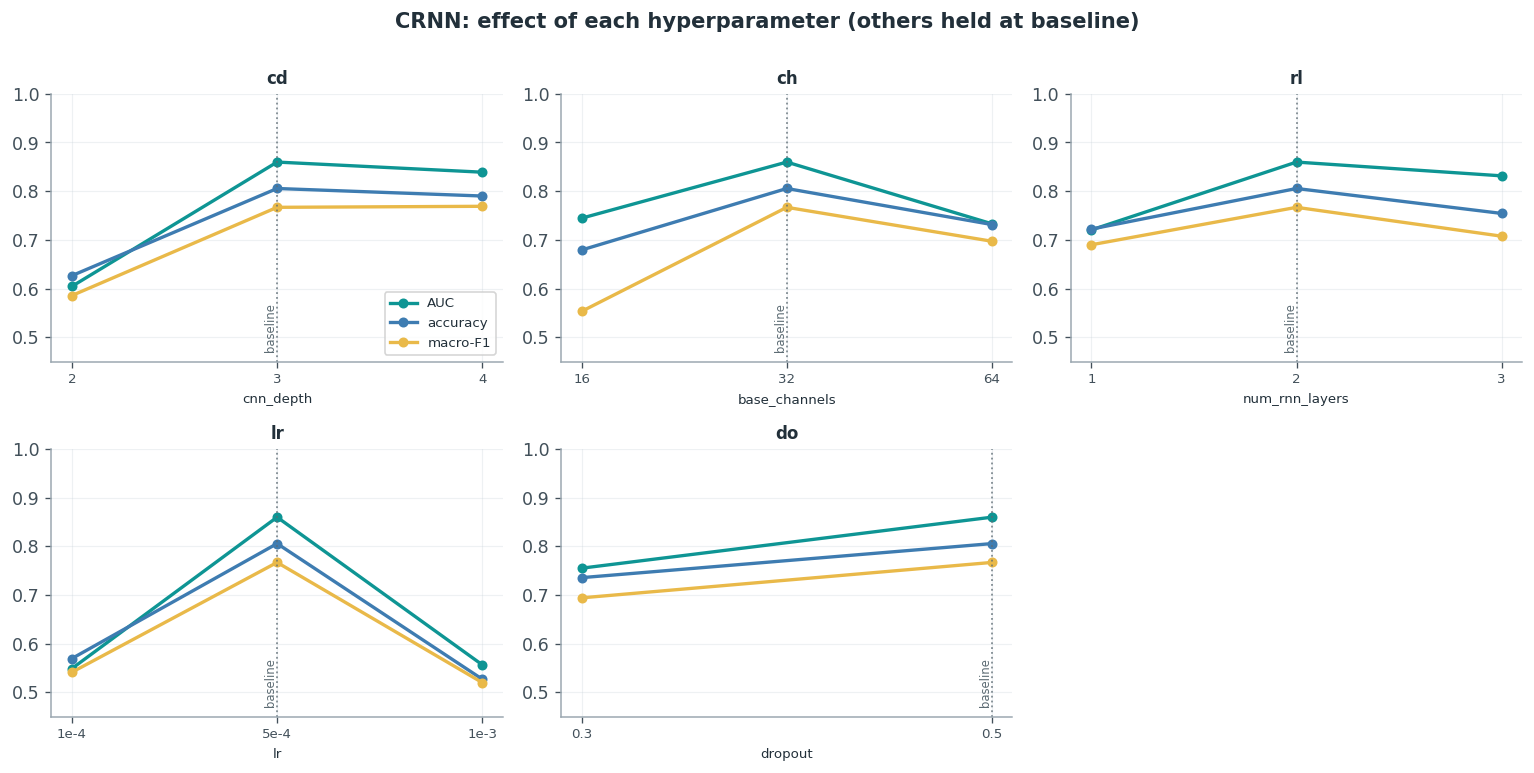

In [10]:
plot_hparam_effects("CRNN", "crnn_experiments/crnn")

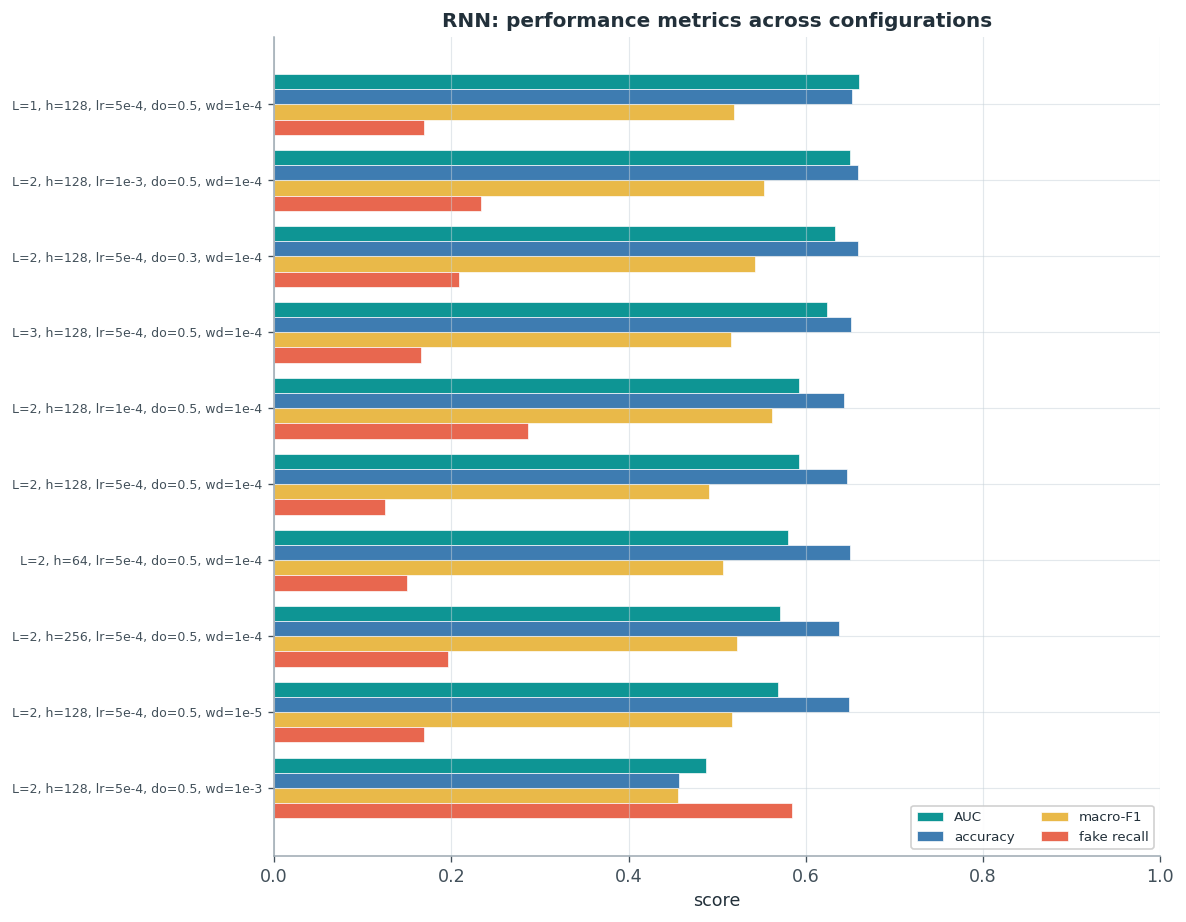

In [11]:
plot_family("RNN", "rnn_experiments/rnn")

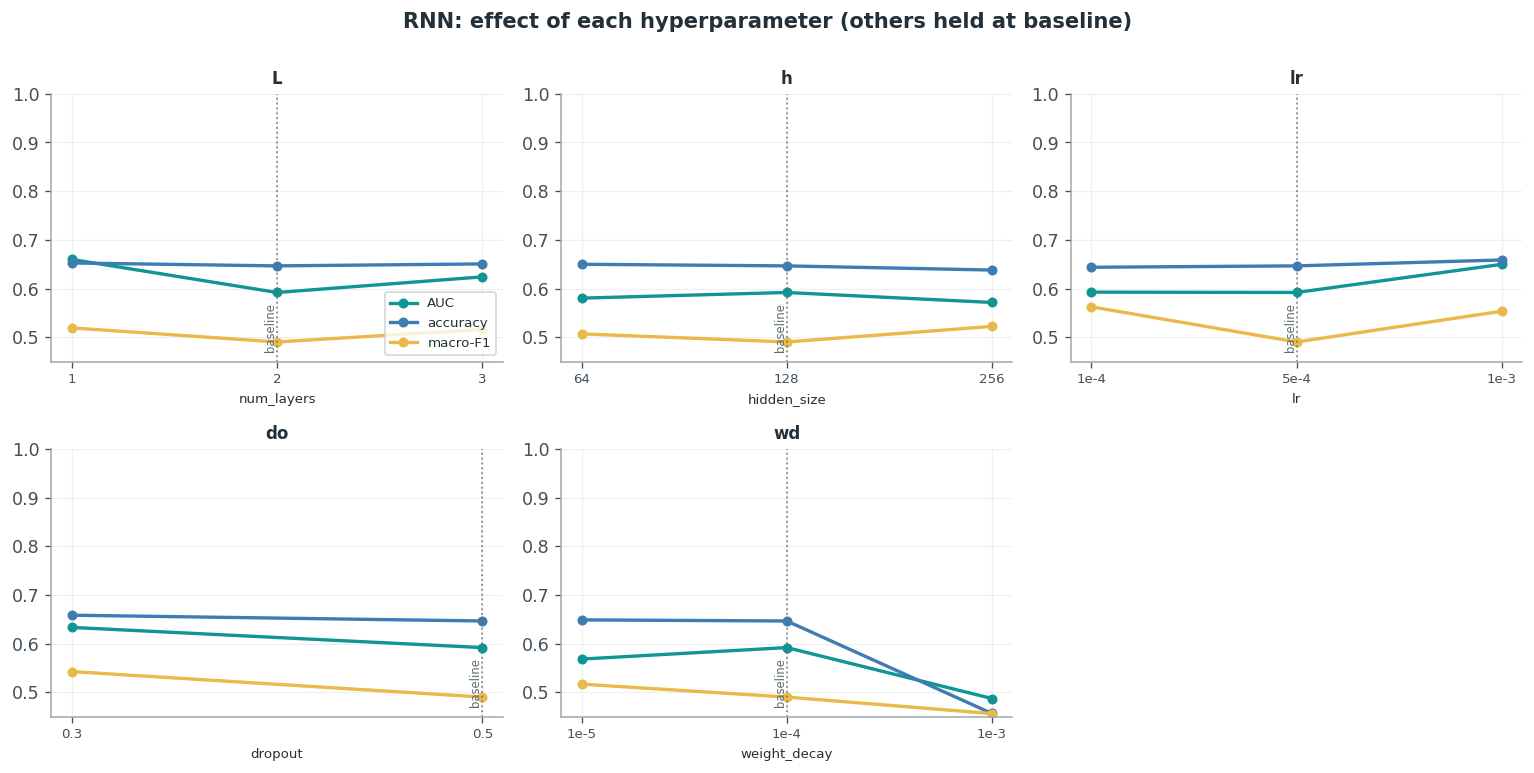

In [12]:
plot_hparam_effects("RNN", "rnn_experiments/rnn")

**Interpretation - the CNN front-end is what matters.**

- **CRNN reaches AUC ~ 0.86**, matching the pure CNN, while the **pure RNN tops out at 0.66**, barely above the MLP. Without a convolutional front-end the BiLSTM must learn both *what* the local patterns are and *how* they evolve, and does the first poorly.
- **CRNN** wins with the same recipe as the CNN; larger LR (`1e-3`) destabilises the recurrent path (AUC 0.56).
- **Pure RNN** gains nothing from more layers / wider hidden - bottlenecked by representation, not temporal capacity.

**Takeaway:** the discriminative work is **convolutional**; explicit temporal modelling adds little once a CNN front-end is present.

## 7. Architecture 4 - WavLM (self-supervised backbone)
`microsoft/wavlm-base-plus` consumes the **raw waveform**. Two usage modes:

- **Frozen probe** - backbone frozen; learn a softmax-weighted sum over its 13 hidden states + a linear head. Reveals *which layer encodes the spoofing cue*.
- **Full fine-tune** - entire backbone trainable (low LR) with online train-time augmentation (MUSAN noise / RIR reverb / codec). The **best** such variant is reported below.

In [13]:
probe = json.load(open(RESULTS / "wavlm_base_plus/metrics_20260616_213734.json"))

ft = []
for p in (RESULTS / "wavlm_base_plus_finetune").glob("metrics_*.json"):
    d = json.load(open(p))
    if "itw_test" in d and "auc" in d["itw_test"]:
        ft.append((d["itw_test"]["auc"], p.name, d))
ft.sort(reverse=True)
best_ft_auc, best_ft_name, best_ft = ft[0]
print(f"Best fine-tune variant by ITW AUC: {best_ft_name}  (ITW AUC {best_ft_auc:.4f})")

def wl_row(name, d):
    v, t = d["for_val"], d["itw_test"]
    return {"variant": name, "FoR_AUC": v["auc"], "FoR_acc": v["acc"],
            "ITW_AUC": t["auc"], "ITW_acc": t["acc"],
            "ITW_fake_recall": t["recall_fake"], "ITW_fake_F1": t["f1_fake"]}

wavlm_df = pd.DataFrame([wl_row("frozen probe (weighted-sum)", probe),
                         wl_row("full fine-tune (best)", best_ft)])
wavlm_df

Best fine-tune variant by ITW AUC: metrics_20260616_202138_top4_codec.json  (ITW AUC 0.8500)


,variant,FoR_AUC,FoR_acc,ITW_AUC,ITW_acc,ITW_fake_recall,ITW_fake_F1
0,frozen probe (weighted-sum),0.9821,0.9135,0.9171,0.8111,0.5682,0.6910
1,full fine-tune (best),0.9949,0.9584,0.8500,0.7264,0.3883,0.5135


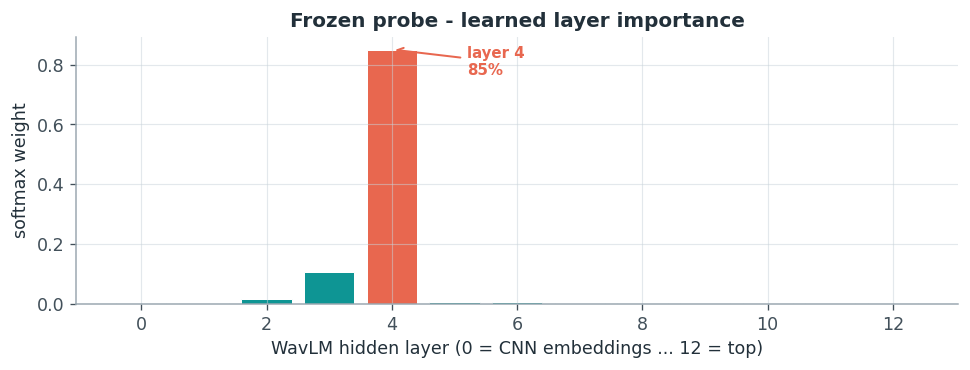

Dominant layer: 4 (weight 0.85)


In [14]:
w = probe["layer_weights_softmax"]
dom = int(np.argmax(w))
colors = [PAL["coral"] if i == dom else PAL["teal"] for i in range(len(w))]
plt.figure(figsize=(8.2,3.2))
bars = plt.bar(range(len(w)), w, color=colors, edgecolor="white", linewidth=0.6)
plt.annotate(f"layer {dom}\n{w[dom]:.0%}", xy=(dom, w[dom]), xytext=(dom+1.2, w[dom]*0.9),
             color=PAL["coral"], fontweight="bold", fontsize=9,
             arrowprops=dict(arrowstyle="->", color=PAL["coral"], lw=1.2))
plt.xlabel("WavLM hidden layer (0 = CNN embeddings ... 12 = top)")
plt.ylabel("softmax weight"); plt.title("Frozen probe - learned layer importance")
plt.tight_layout(); plt.show()
print("Dominant layer:", dom, f"(weight {max(w):.2f})")

**Interpretation - two key findings.**

**(a) The spoofing cue lives in the *middle* of the network.** The probe puts **~85% of its weight on layer 4** (of 12), almost nothing on the top. WavLM upper layers specialise toward the self-supervised phonetic/content objective; the **mid layers retain low-level acoustic detail** where synthesis artefacts (unnatural phase, spectral smoothing, vocoder fingerprints) are most visible. A naive last-layer head would have discarded the most useful signal.

**(b) Under domain shift, the frozen probe *beats* full fine-tuning.** The probe hits **ITW AUC 0.917** - the best cross-dataset result here - while the best fine-tune drives **FoR AUC to ~0.99** yet only reaches **ITW AUC 0.85**, with **fake recall collapsing to ~0.39**. Fine-tuning lets the backbone memorise FoR-specific artefacts at the cost of general features that transfer to ITW - a textbook **source-domain overfitting** trade-off. With a strong pretrained backbone and a test-time domain shift, **freezing can be the better choice.**

## 8. Cross-architecture comparison
The most important section: best configuration per family **plus both WavLM modes**, with **full per-class metrics**. Feature-model per-class numbers are parsed from each run saved classification report.

In [15]:
def parse_clf_report(txt_path):
    t = Path(txt_path).read_text(); out = {}
    for cls in ("Real", "Fake"):
        m = re.search(cls + r"\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)", t)
        out[cls] = tuple(float(x) for x in m.groups()[:3])
    return out

def feat_row(fam, sub):
    top = summ[fam].iloc[0]; tag = top["tag"]
    rep = parse_clf_report(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
    Rp, Rr, Rf = rep["Real"]; Fp, Fr, Ff = rep["Fake"]
    return {"model": fam, "config/mode": tag, "ITW_AUC": top["auc"], "ITW_acc": top["test_acc"],
            "real_P": Rp, "real_R": Rr, "real_F1": Rf, "fake_P": Fp, "fake_R": Fr, "fake_F1": Ff, "macro_F1": (Rf+Ff)/2}

def wl_full(name, d):
    t = d["itw_test"]
    return {"model": name, "config/mode": "wavlm-base-plus", "ITW_AUC": t["auc"], "ITW_acc": t["acc"],
            "real_P": t["precision_real"], "real_R": t["recall_real"], "real_F1": t["f1_real"],
            "fake_P": t["precision_fake"], "fake_R": t["recall_fake"], "fake_F1": t["f1_fake"], "macro_F1": (t["f1_real"]+t["f1_fake"])/2}

rows = [feat_row(f, s) for f, s in FAM.items()]
rows.append(wl_full("WavLM (fine-tune, best)", best_ft))
rows.append(wl_full("WavLM (frozen probe)", probe))
master = pd.DataFrame(rows).sort_values("ITW_AUC", ascending=False).reset_index(drop=True)
master = master[["model","config/mode","ITW_AUC","ITW_acc","macro_F1","real_P","real_R","real_F1","fake_P","fake_R","fake_F1"]]
master

,model,config/mode,ITW_AUC,ITW_acc,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,WavLM (frozen probe),wavlm-base-plus,0.9171,0.8111,0.7775,0.7889,0.9548,0.8639,0.8816,0.5682,0.6910
1,CNN,CNN_d3_ch32_lr1e-3_do0.5_wd1e-4,0.8702,0.8266,0.8103,0.8418,0.8914,0.8659,0.7963,0.7170,0.7546
2,CRNN,CRNN_cd3_ch32_rl2_rh128_lr5e-4_do0.5_wd1e-4,0.8596,0.8054,0.7667,0.7783,0.9651,0.8617,0.9008,0.5355,0.6717
3,"WavLM (fine-tune, best)",wavlm-base-plus,0.8500,0.7264,0.6616,0.7190,0.9265,0.8097,0.7577,0.3883,0.5135
4,MLP,NN_h256-128-64_lr1e-3_do0.5_wd1e-4,0.7864,0.6832,0.5436,0.6667,0.9873,0.7960,0.8914,0.1740,0.2912
5,RNN,RNN_l1_h128_lr5e-4_do0.5_wd1e-4,0.6596,0.6524,0.5191,0.6562,0.9384,0.7723,0.6194,0.1693,0.2659


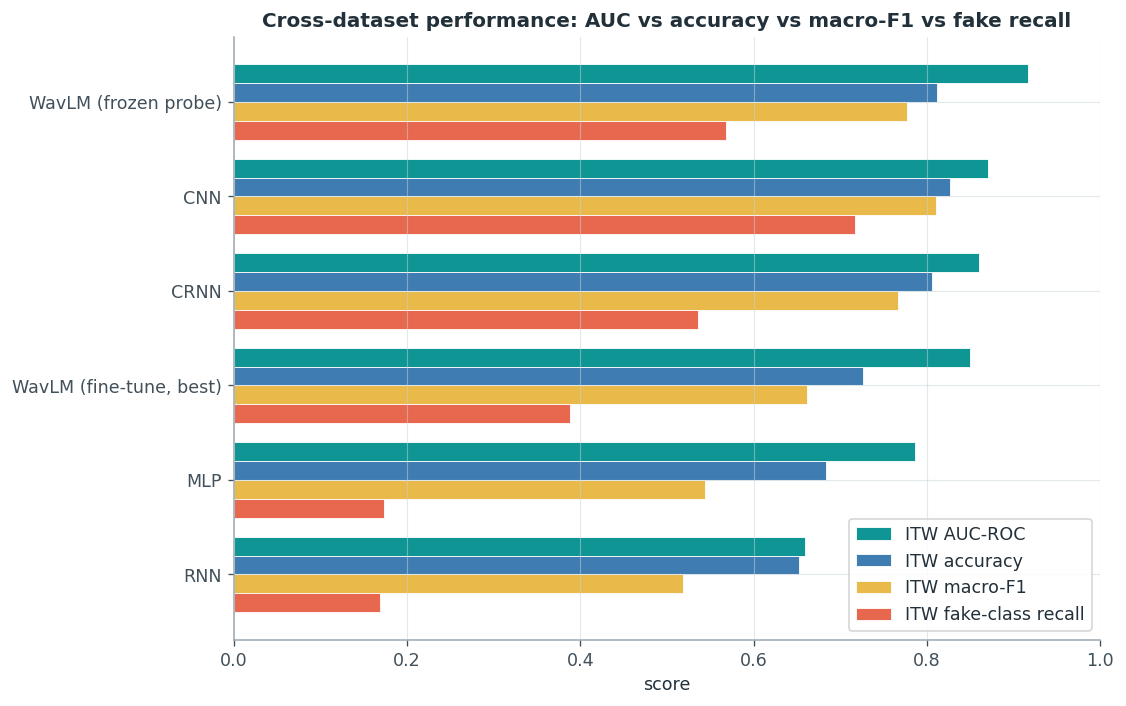

In [16]:
m = master.set_index("model")
order = m.sort_values("ITW_AUC").index
x = np.arange(len(order)); h = 0.2
plt.figure(figsize=(9.5,6))
plt.barh(x+1.5*h, m.loc[order,"ITW_AUC"],  h, label="ITW AUC-ROC",           color=PAL["teal"],  edgecolor="white", linewidth=0.5)
plt.barh(x+0.5*h, m.loc[order,"ITW_acc"],  h, label="ITW accuracy",          color=PAL["blue"],  edgecolor="white", linewidth=0.5)
plt.barh(x-0.5*h, m.loc[order,"macro_F1"], h, label="ITW macro-F1",          color=PAL["amber"], edgecolor="white", linewidth=0.5)
plt.barh(x-1.5*h, m.loc[order,"fake_R"],   h, label="ITW fake-class recall", color=PAL["coral"], edgecolor="white", linewidth=0.5)
plt.yticks(x, order); plt.xlim(0,1.0); plt.xlabel("score")
plt.title("Cross-dataset performance: AUC vs accuracy vs macro-F1 vs fake recall")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Reading the comparison.**

- **By AUC**, the ranking is clean: **WavLM probe (0.92) > CNN (0.87) ~ CRNN (0.86) > WavLM fine-tune (0.85) > MLP (0.79) > RNN (0.66)**.
- **By macro-F1** (the balanced average across both classes), the real-biased models are penalised hard: the MLP and RNN fall well behind because their fake-class F1 is ~0.27-0.29, while the CNN, CRNN and frozen WavLM probe stay strong - macro-F1 exposes the imbalance that plain accuracy hides.
- **By fake recall**, the picture sharpens and partly *reorders*. The **CNN catches ~72% of fakes** - the best at its operating point - whereas the **MLP and RNN catch only ~17%**: they ride the 63% "real" majority to a passable accuracy while being nearly useless as detectors. Even the high-AUC WavLM fine-tune flags only ~39% of fakes at its threshold, a direct symptom of the domain shift.
- The central lesson of the imbalance: **a respectable accuracy or AUC does not imply a usable detector.** The CNN and the frozen WavLM probe are the only models both well-ranked *and* operationally effective at catching fakes.

### 8.1 Generalisation gap (FoR -> ITW)
How much does each model lose moving from in-domain validation to the cross-dataset test? A large gap signals overfitting to FoR-specific artefacts.

,model,FoR_val_acc,ITW_acc,drop
0,CNN,0.7359,0.8266,-0.0907
1,MLP,0.6770,0.6832,-0.0062
2,CRNN,0.8343,0.8054,0.0289
3,WavLM probe,0.9135,0.8111,0.1024
4,WavLM fine-tune,0.9584,0.7264,0.2320
5,RNN,0.9530,0.6524,0.3005


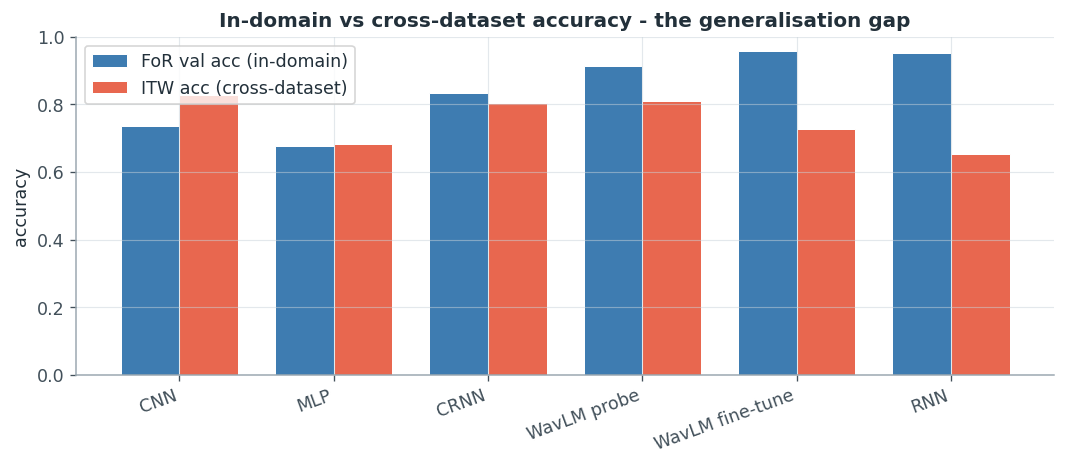

In [17]:
gap_rows = []
for fam, sub in FAM.items():
    top = summ[fam].iloc[0]
    hist = json.load(open(RESULTS / sub / "experiments" / top["tag"] / "checkpoints" / ("history_" + top["tag"] + ".json")))
    for_acc = max(hist["val_acc"])
    gap_rows.append({"model": fam, "FoR_val_acc": for_acc, "ITW_acc": top["test_acc"], "drop": for_acc - top["test_acc"]})
gap_rows.append({"model": "WavLM probe", "FoR_val_acc": probe["for_val"]["acc"], "ITW_acc": probe["itw_test"]["acc"], "drop": probe["for_val"]["acc"] - probe["itw_test"]["acc"]})
gap_rows.append({"model": "WavLM fine-tune", "FoR_val_acc": best_ft["for_val"]["acc"], "ITW_acc": best_ft["itw_test"]["acc"], "drop": best_ft["for_val"]["acc"] - best_ft["itw_test"]["acc"]})
gap = pd.DataFrame(gap_rows).sort_values("drop").reset_index(drop=True)
display(gap)

g = gap.set_index("model"); x = np.arange(len(g)); h = 0.38
plt.figure(figsize=(9,4))
plt.bar(x-h/2, g["FoR_val_acc"], h, label="FoR val acc (in-domain)", color=PAL["blue"],  edgecolor="white", linewidth=0.6)
plt.bar(x+h/2, g["ITW_acc"], h, label="ITW acc (cross-dataset)", color=PAL["coral"], edgecolor="white", linewidth=0.6)
plt.xticks(x, g.index, rotation=20, ha="right"); plt.ylim(0,1.0); plt.ylabel("accuracy")
plt.title("In-domain vs cross-dataset accuracy - the generalisation gap")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** The **fine-tuned WavLM shows the widest gap** - near-perfect FoR accuracy crashing on ITW - confirming source-domain overfitting. The **frozen probe transfers best** (small gap, highest ITW). Among from-scratch models the CNN/CRNN gap is moderate, while the MLP/RNN gap is partly masked because they are weak in both domains.

### 8.2 Training dynamics
Validation-accuracy curves for the best run of each from-scratch family.

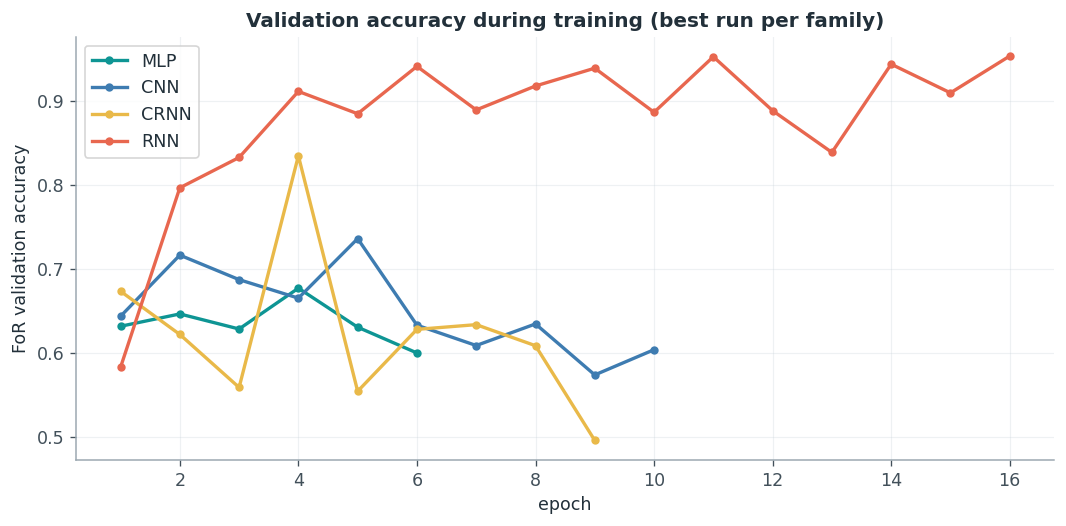

In [18]:
cyc = [PAL["teal"], PAL["blue"], PAL["amber"], PAL["coral"]]
plt.figure(figsize=(9,4.5))
for (fam, sub), col in zip(FAM.items(), cyc):
    top = summ[fam].iloc[0]
    hist = json.load(open(RESULTS / sub / "experiments" / top["tag"] / "checkpoints" / ("history_" + top["tag"] + ".json")))
    plt.plot(range(1, len(hist["val_acc"])+1), hist["val_acc"], marker="o", ms=4, lw=2, color=col, label=fam)
plt.xlabel("epoch"); plt.ylabel("FoR validation accuracy")
plt.title("Validation accuracy during training (best run per family)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 9. Noise robustness & augmentation
Robustness is currently addressed on the **training side**: the WavLM fine-tune uses an online waveform-augmentation pipeline - **MUSAN additive noise (0-15 dB SNR), simulated-RIR reverberation, and codec compression** - applied to the **training split only** to prevent leakage.

A dedicated **evaluation-side** study is the planned extension: corrupt the **test** set at fixed SNRs (e.g. 10 dB, 0 dB) and reverberation, then re-score every checkpoint to produce an **AUC-vs-SNR degradation curve** per architecture. It is inference-only - WavLM scores corrupted waveforms directly; feature models corrupt the waveform, re-extract with the saved clean scaler, and score - reusing the existing augmentation pipeline run deterministically over a **held-out** noise/RIR partition disjoint from training.

## 10. Conclusions

- **Representation learning is the dominant factor in cross-dataset AUC:** hand-crafted+MLP (0.79) -> learned CNN/CRNN (0.86-0.87) -> self-supervised WavLM (0.92).
- **Accuracy/AUC must be read together with fake-class recall.** On imbalanced ITW the MLP and RNN catch only ~17% of fakes despite passable accuracy; the CNN (~72%) and frozen WavLM probe are the only both-well-ranked-and-operationally-effective detectors.
- **Convolution carries the recurrent path** - pure BiLSTM 0.66 vs CRNN 0.86.
- **Capacity and regularisation must be tuned, not maximised** - middle depth/width and moderate weight decay generalise best.
- **For a pretrained backbone under domain shift, freezing beats fine-tuning** - the frozen probe is the best cross-dataset model; fine-tuning saturates FoR (AUC ~0.99) and loses ITW transfer.
- **The spoofing cue is a mid-network acoustic feature** - WavLM layer 4 dominates the probe.

**Future work.** Evaluation-side noise-robustness curves (Section 9); EER reporting alongside AUC; multi-seed runs for error bars; threshold calibration to lift fake recall on the high-AUC models.
